In [1]:

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt


EXPORT_DIR = "/content/drive/MyDrive/EarthEngineExports"


pattern = os.path.join(EXPORT_DIR, "Stirling_2024_??_*NDVI*.tif")
files = sorted(glob.glob(pattern))

print("Found files:")
for f in files:
    print(" -", os.path.basename(f))


wanted = ["2024_06", "2024_07", "2024_08", "2024_09"]
ndvi_files = {}
for tag in wanted:
    matches = [f for f in files if tag in f]
    if matches:
        ndvi_files[tag] = matches[0]

print("\nSelected NDVI files:")
for k,v in ndvi_files.items():
    print(k, "=>", os.path.basename(v))


def read_ndvi(path):
    """Read NDVI raster as masked array, handling nodata."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
        mask = np.isfinite(arr)
        if nodata is not None:
            mask &= (arr != nodata)

        mask &= (arr >= -1.0) & (arr <= 1.0)

        out = np.ma.array(arr, mask=~mask)
        return out

def save_ndvi_png(ndvi, title, out_path, vmin=0.0, vmax=0.9):
    """Save a clean NDVI map with consistent scale + colorbar."""
    plt.figure(figsize=(7.5, 6.5))
    im = plt.imshow(ndvi, vmin=vmin, vmax=vmax)
    plt.axis("off")
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("NDVI")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()

def ndvi_stats(ndvi):
    """Compute mean/std on valid pixels only."""
    data = ndvi.compressed()
    return float(data.mean()), float(data.std()), int(data.size)


OUT_DIR = "/content/ndvi_figures"
os.makedirs(OUT_DIR, exist_ok=True)

vmin, vmax = 0.0, 0.9

month_order = ["2024_06", "2024_07", "2024_08", "2024_09"]

for tag in month_order:
    path = ndvi_files.get(tag)
    if not path:
        print(f"Skipping {tag} (file not found)")
        continue

    ndvi = read_ndvi(path)
    mean, std, n = ndvi_stats(ndvi)

    title = f"NDVI Composite — {tag.replace('_','-')} (mean={mean:.3f}, sd={std:.3f})"
    out_path = os.path.join(OUT_DIR, f"NDVI_{tag}.png")

    save_ndvi_png(ndvi, title, out_path, vmin=vmin, vmax=vmax)

    print(f"{tag}: mean={mean:.4f}, std={std:.4f}, n={n} -> {out_path}")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

ims = []
for i, tag in enumerate(month_order):
    ax = axes[i]
    path = ndvi_files.get(tag)
    if not path:
        ax.set_axis_off()
        ax.set_title(f"{tag} (missing)")
        continue

    ndvi = read_ndvi(path)
    mean, std, _ = ndvi_stats(ndvi)

    im = ax.imshow(ndvi, vmin=vmin, vmax=vmax)
    ims.append(im)
    ax.set_title(f"{tag.replace('_','-')}\nmean={mean:.3f}, sd={std:.3f}")
    ax.set_axis_off()


if ims:
    cbar = fig.colorbar(ims[-1], ax=axes.tolist(), fraction=0.03, pad=0.02)
    cbar.set_label("NDVI")

fig.suptitle("Seasonal NDVI Progression (Adaptive Monthly Composites, 2024)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

panel_path = os.path.join(OUT_DIR, "NDVI_2024_Jun-Sep_PANEL.png")
plt.savefig(panel_path, dpi=300)
plt.close()

print("\nSaved panel figure:", panel_path)
print("All outputs in:", OUT_DIR)


MessageError: Error: credential propagation was unsuccessful

In [ ]:
from IPython.display import Image, display
import os

folder = "/content/ndvi_figures"

files = sorted(os.listdir(folder))
for f in files:
    if f.endswith(".png"):
        print(f)
        display(Image(os.path.join(folder, f)))

Output hidden; open in https://colab.research.google.com to view.

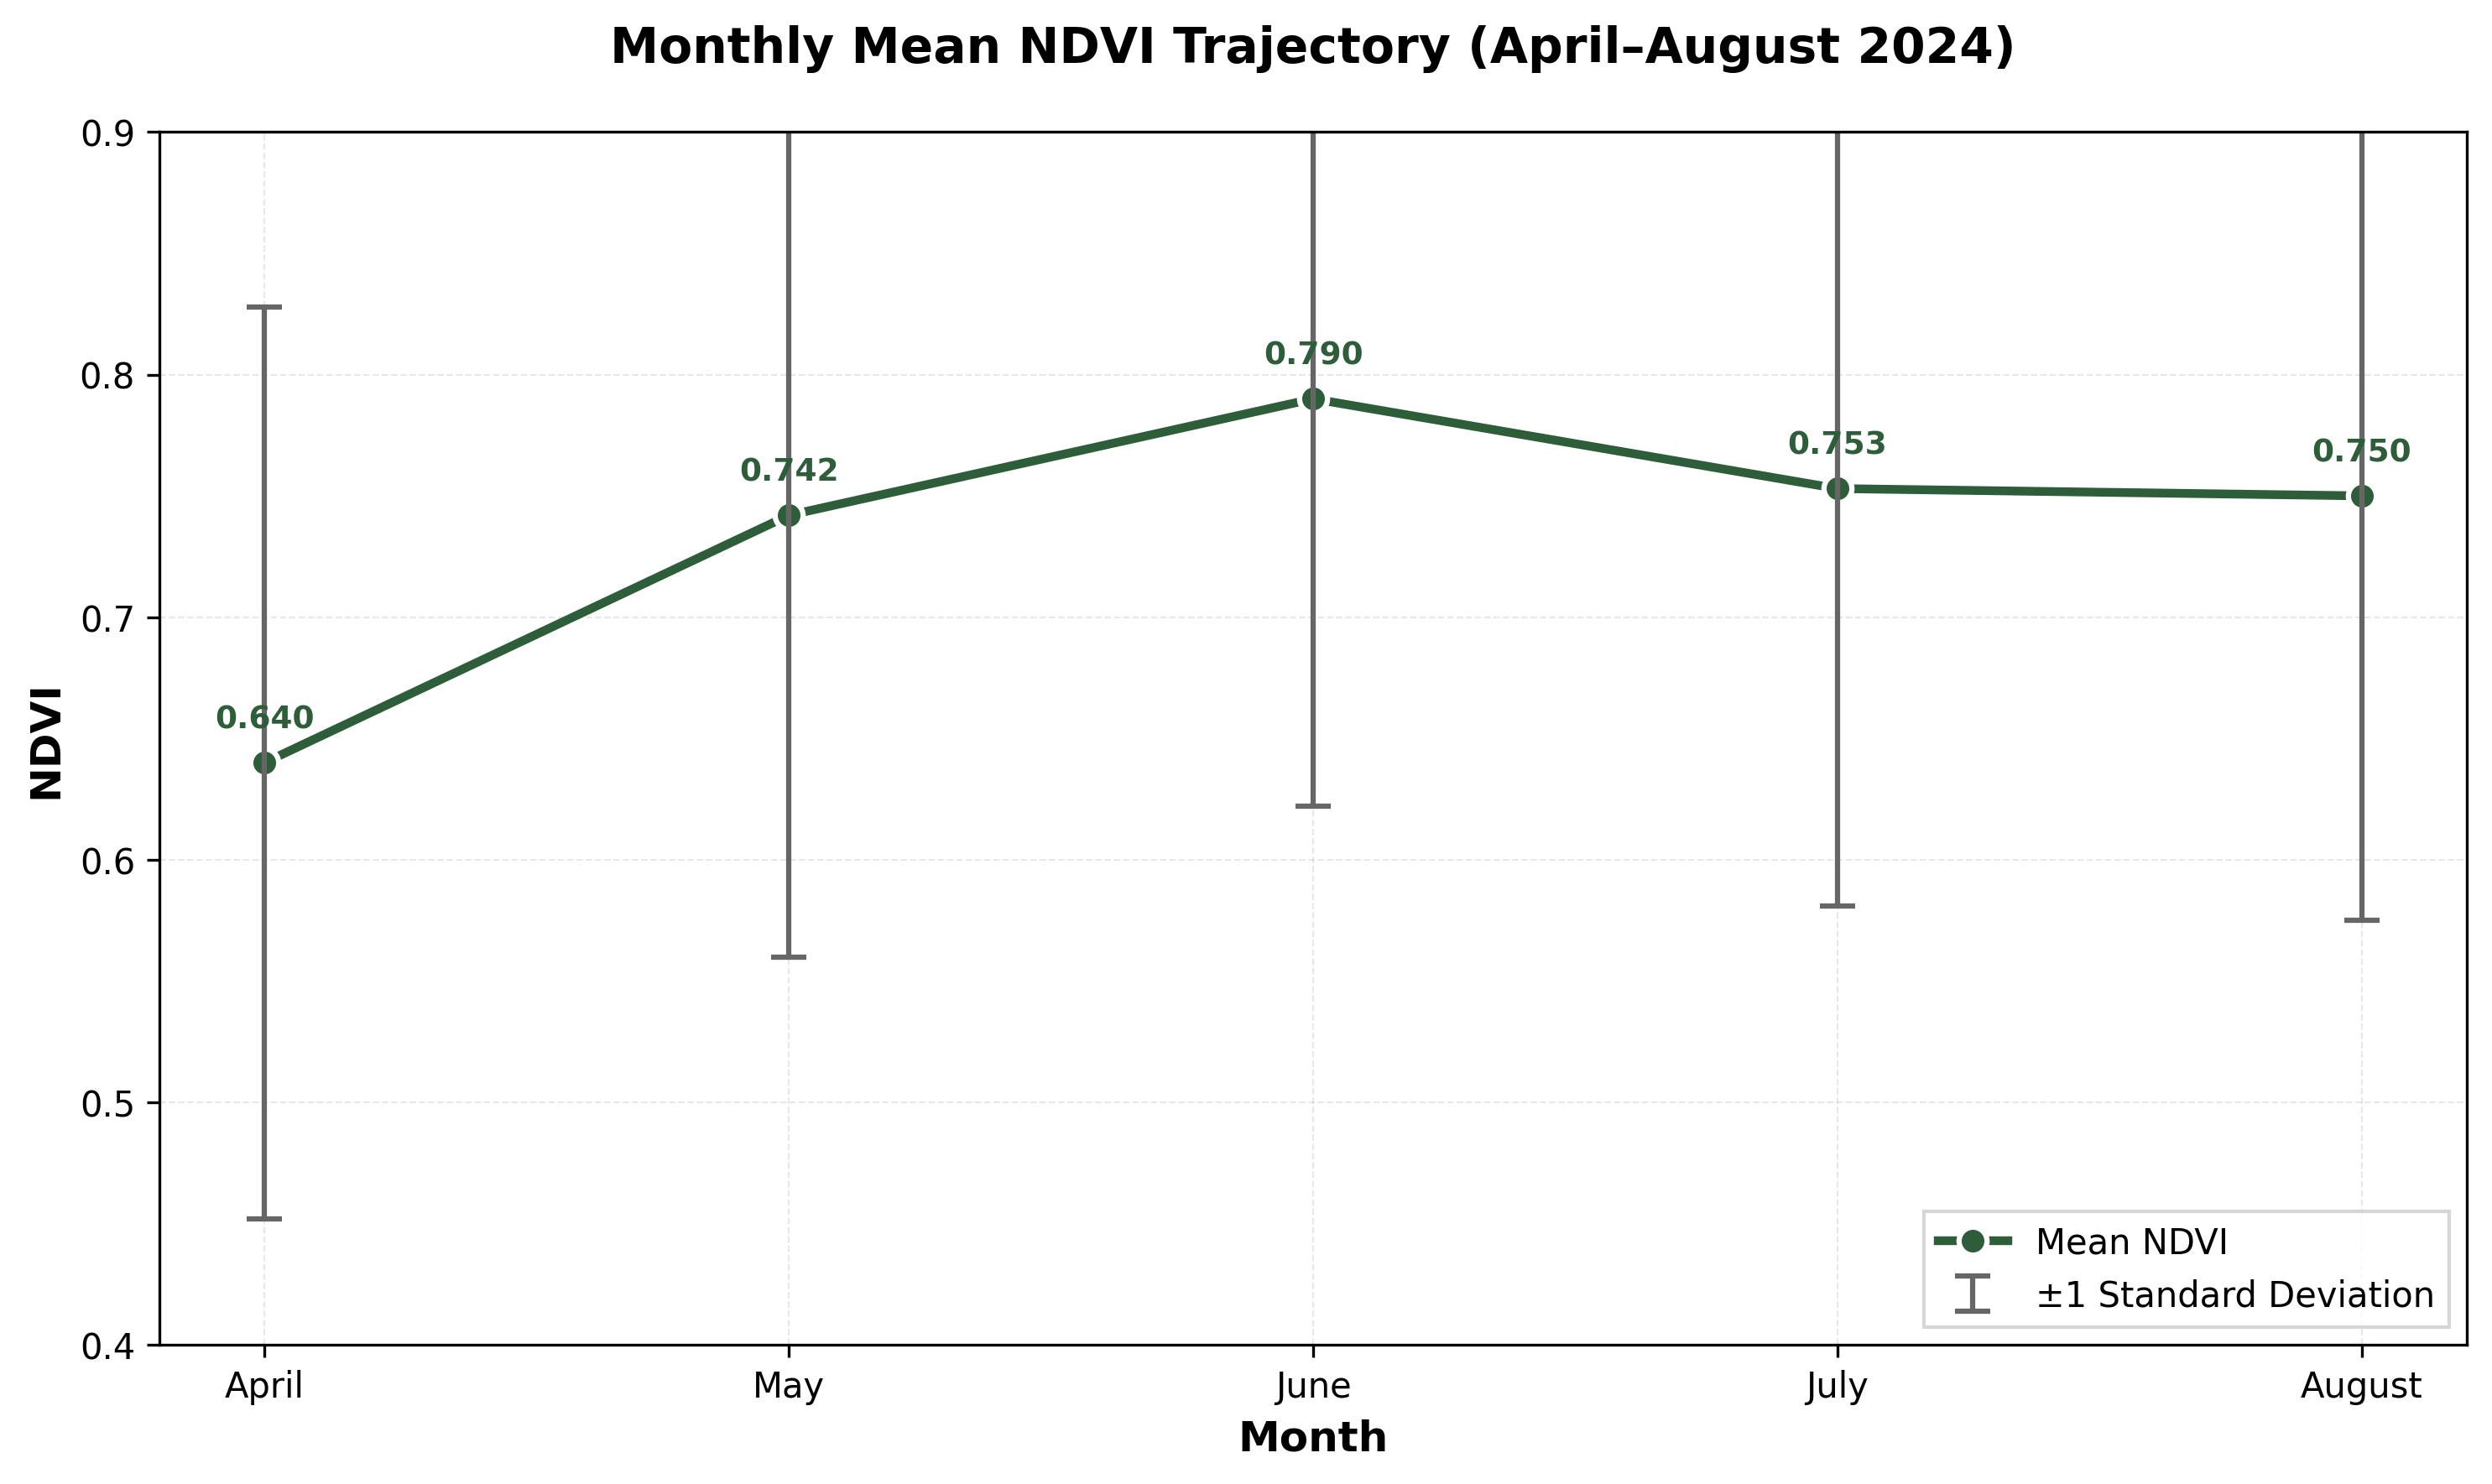


📊 Summary Statistics:
----------------------------------------
April    | Mean: 0.640 | Std: 0.188
May      | Mean: 0.742 | Std: 0.182
June     | Mean: 0.790 | Std: 0.168
July     | Mean: 0.753 | Std: 0.172
August   | Mean: 0.750 | Std: 0.175


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


months = ['April', 'May', 'June', 'July', 'August']
ndvi_means = [0.640, 0.742, 0.790, 0.753, 0.750]
ndvi_stds = [0.188, 0.182, 0.168, 0.172, 0.175]


plt.figure(figsize=(10, 6), dpi=300)


plt.plot(months, ndvi_means, 'o-', color='#2E5D3A', linewidth=2.5,
         markersize=8, markerfacecolor='#2E5D3A', markeredgecolor='white',
         markeredgewidth=1.5, label='Mean NDVI')


plt.errorbar(months, ndvi_means, yerr=ndvi_stds, fmt='none',
             ecolor='#666666', capsize=5, capthick=1.5,
             elinewidth=1.5, label='±1 Standard Deviation')


plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('NDVI', fontsize=12, fontweight='bold')
plt.title('Monthly Mean NDVI Trajectory (April–August 2024)',
          fontsize=14, fontweight='bold', pad=20)

plt.ylim(0.4, 0.9)


plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)


plt.legend(loc='lower right', frameon=True, fancybox=False, fontsize=10)


for i, (month, mean) in enumerate(zip(months, ndvi_means)):
    plt.annotate(f'{mean:.3f}',
                xy=(month, mean),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                fontweight='bold',
                color='#2E5D3A')




plt.tight_layout()


plt.savefig('Figure_5.4_NDVI_Trajectory.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_5.4_NDVI_Trajectory.pdf', bbox_inches='tight')


plt.show()


print("\n📊 Summary Statistics:")
print("-" * 40)
for month, mean, std in zip(months, ndvi_means, ndvi_stds):
    print(f"{month:8} | Mean: {mean:.3f} | Std: {std:.3f}")

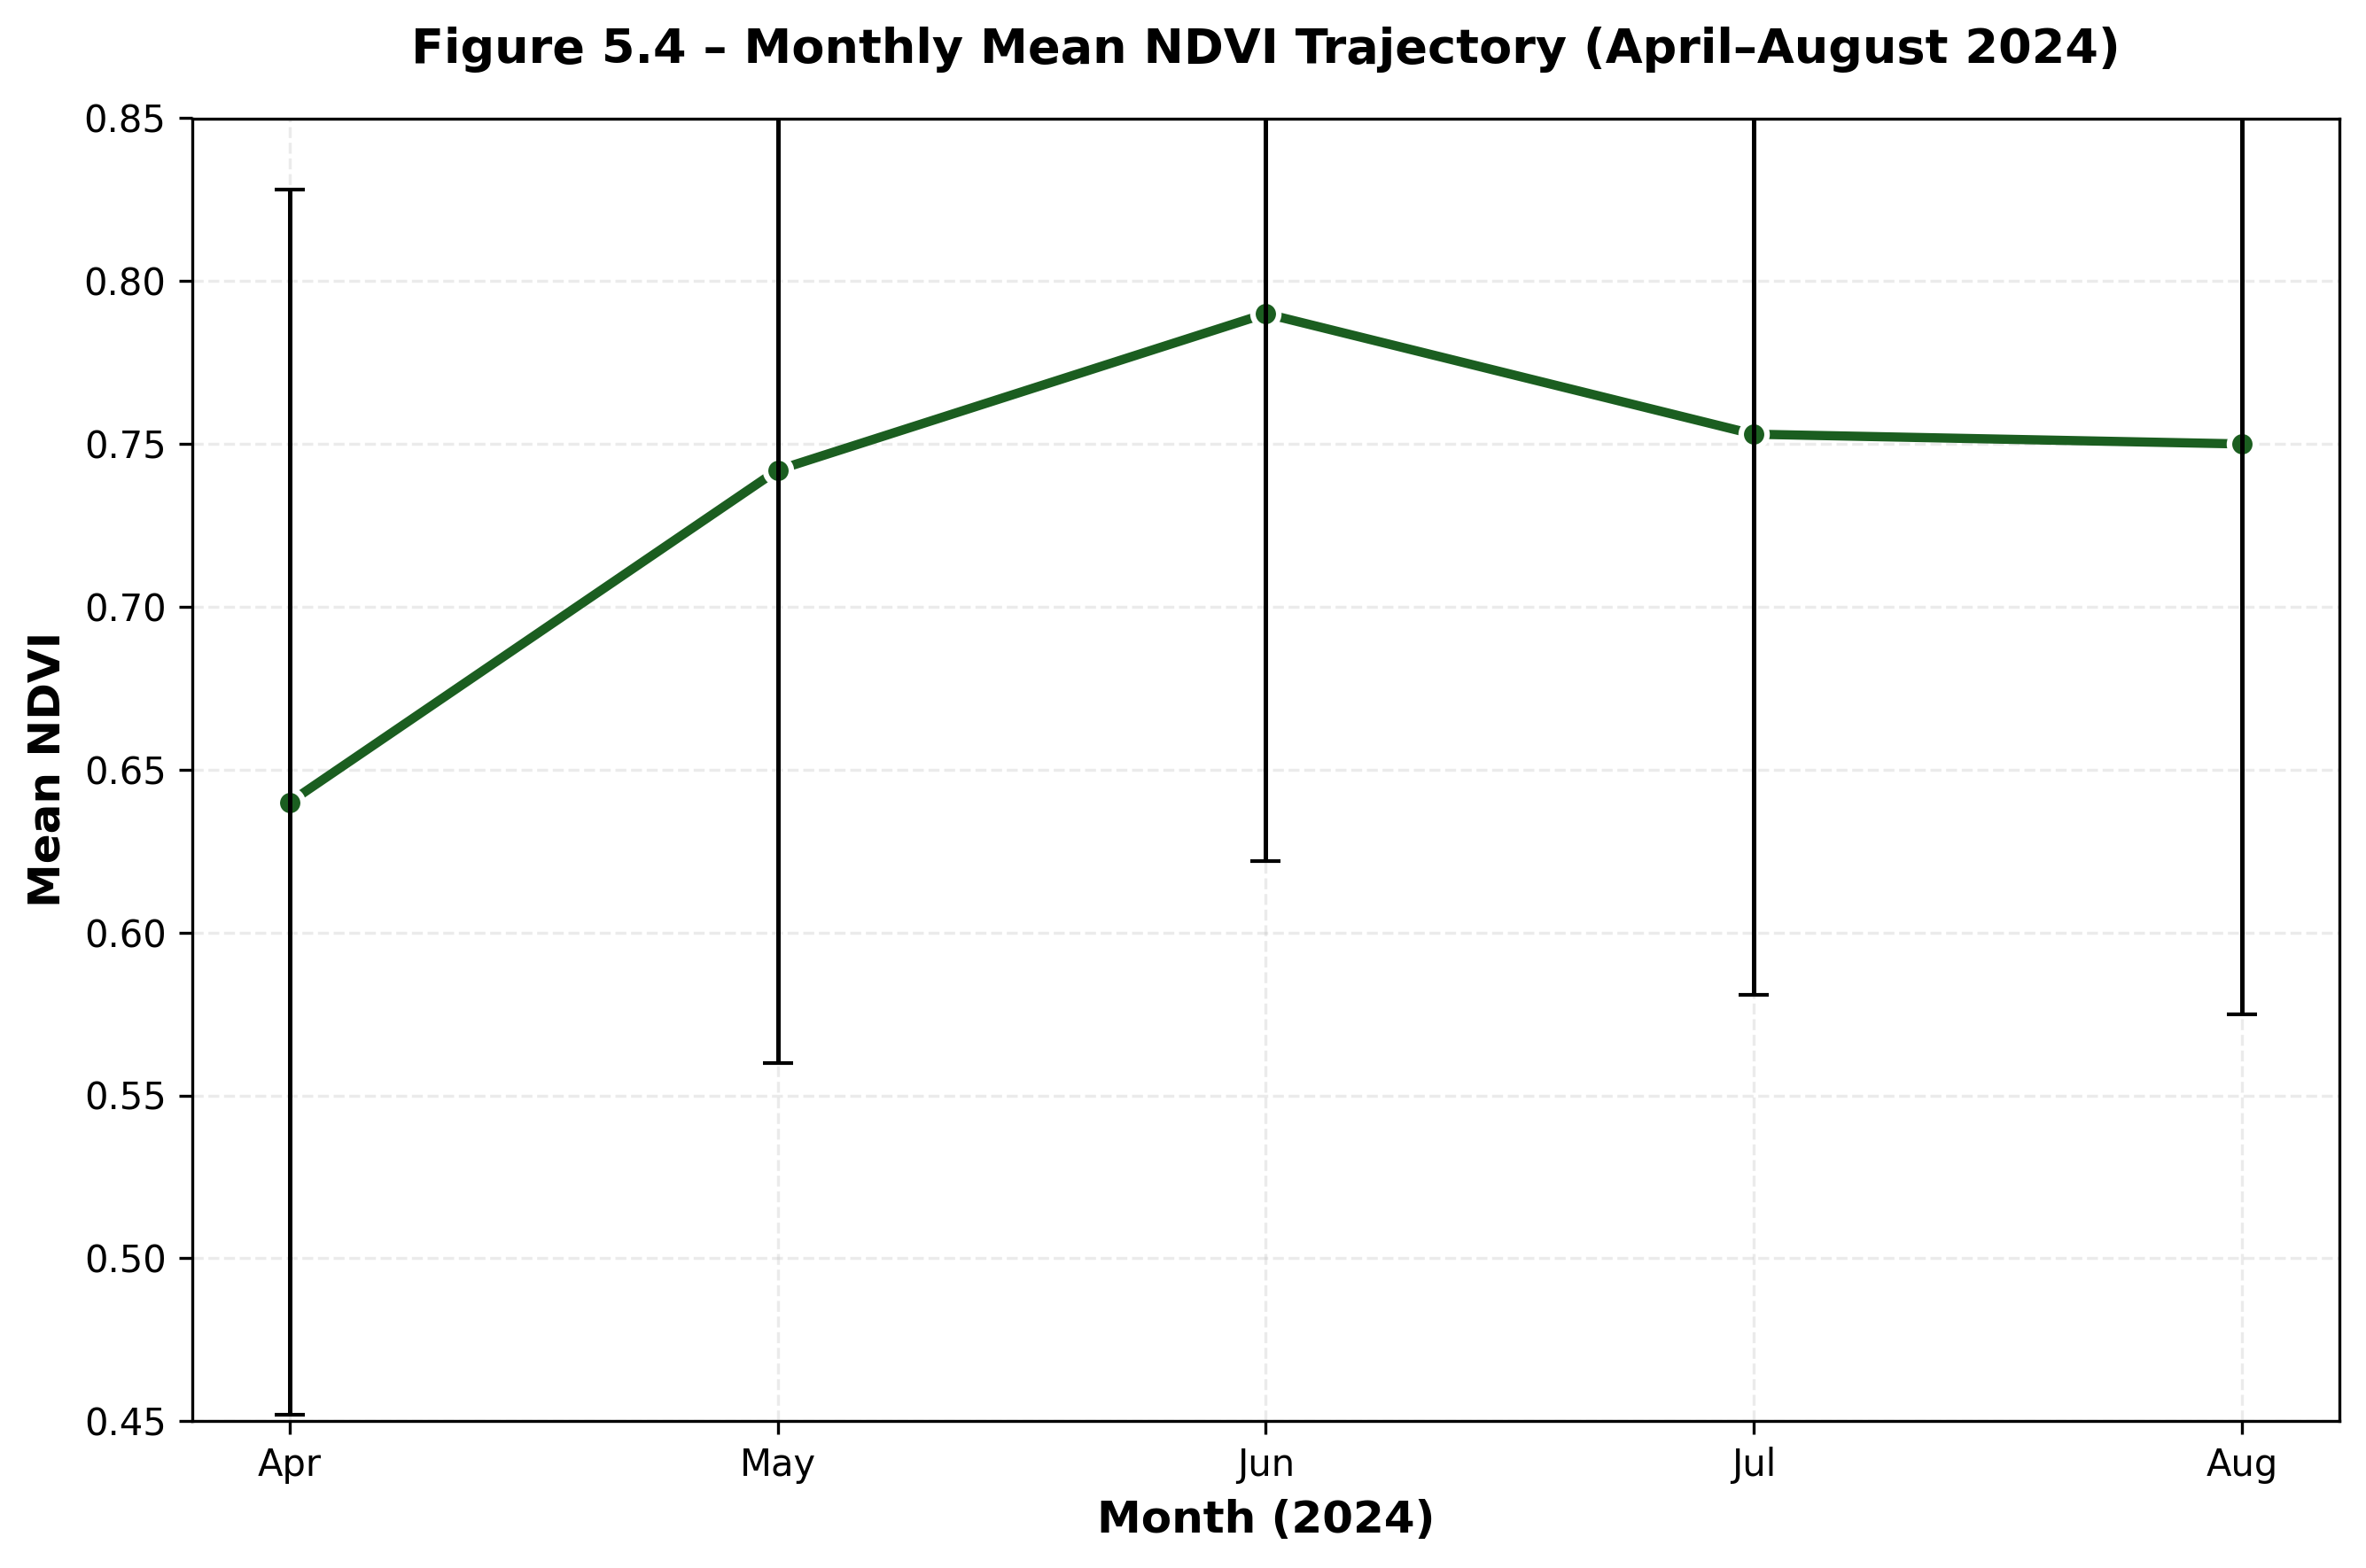


📊 Summary Statistics
----------------------------------------
Apr   | Mean = 0.640 | Std = 0.188
May   | Mean = 0.742 | Std = 0.182
Jun   | Mean = 0.790 | Std = 0.168
Jul   | Mean = 0.753 | Std = 0.172
Aug   | Mean = 0.750 | Std = 0.175


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


months = ['Apr', 'May', 'Jun', 'Jul', 'Aug']
ndvi_means = [0.640, 0.742, 0.790, 0.753, 0.750]
ndvi_stds = [0.188, 0.182, 0.168, 0.172, 0.175]


plt.figure(figsize=(9, 6), dpi=300)

plt.plot(months, ndvi_means, 'o-',
         color='#1B5E20', linewidth=2.5,
         markersize=7, markerfacecolor='#1B5E20',
         markeredgecolor='white', markeredgewidth=1.5)


plt.errorbar(months, ndvi_means, yerr=ndvi_stds,
             fmt='none', ecolor='black',
             elinewidth=1.2, capsize=4)


plt.xlabel('Month (2024)', fontsize=12, fontweight='bold')
plt.ylabel('Mean NDVI', fontsize=12, fontweight='bold')
plt.title('Figure 5.4 – Monthly Mean NDVI Trajectory (April–August 2024)',
          fontsize=13, fontweight='bold', pad=15)


plt.ylim(0.45, 0.85)


plt.grid(True, alpha=0.25, linestyle='--')


plt.tight_layout()


plt.savefig('Figure_5.4_NDVI_Trajectory.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_5.4_NDVI_Trajectory.pdf', bbox_inches='tight')

plt.show()


print("\n📊 Summary Statistics")
print("-" * 40)
for m, mean, std in zip(months, ndvi_means, ndvi_stds):
    print(f"{m:5} | Mean = {mean:.3f} | Std = {std:.3f}")

In [ ]:

try:
    import rasterio
except:
    !pip -q install rasterio
    import rasterio

import numpy as np
import matplotlib.pyplot as plt
import os


tif_path = "/content/ndvi_exports/Stirling_2024_06_Adaptive_NDVI/Stirling_2024_06_Adaptive_NDVI.tif"



output_dir = "/content/ndvi_contrast_outputs"
os.makedirs(output_dir, exist_ok=True)


with rasterio.open(tif_path) as src:
    ndvi = src.read(1).astype(np.float32)
    nodata = src.nodata

if nodata is not None:
    ndvi[ndvi == nodata] = np.nan


ndvi = np.clip(ndvi, -1, 1)


valid_pixels = ndvi[~np.isnan(ndvi)]
vmin = np.percentile(valid_pixels, 2)
vmax = np.percentile(valid_pixels, 98)


ndvi_display = ndvi.copy()
ndvi_display[ndvi_display < 0.05] = vmin - 0.05


plt.figure(figsize=(8,8), dpi=300)

im = plt.imshow(
    ndvi_display,
    vmin=vmin,
    vmax=vmax,
    cmap='RdYlGn'
)

plt.title("Stirling – June 2024 Adaptive NDVI (Contrast Enhanced)", fontsize=12)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("NDVI", rotation=270, labelpad=15)

# Save output
output_path = os.path.join(output_dir, "Stirling_2024_06_NDVI_Contrast.png")
plt.savefig(output_path, bbox_inches="tight")
plt.show()

print("✅ Saved to:", output_path)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

import os, glob
import numpy as np
import matplotlib.pyplot as plt


try:
    import rasterio
except ImportError:
    !pip -q install rasterio
    import rasterio


BASE_DIR = "/content/ndvi_exports"


MONTHS = [
    ("April 2024",  "Stirling_2024_04_Adaptive_NDVI"),
    ("May 2024",    "Stirling_2024_05_Adaptive_NDVI"),
    ("June 2024",   "Stirling_2024_06_Adaptive_NDVI"),
    ("July 2024",   "Stirling_2024_07_Adaptive_NDVI"),
    ("August 2024", "Stirling_2024_08_Adaptive_NDVI"),
]

OUT_DIR = "/content/ndvi_contrast_outputs_all"
os.makedirs(OUT_DIR, exist_ok=True)

CMAP = "viridis"
DARKEN_WATER = True
WATER_THRESH = 0.05
WATER_PUSH = 0.05


def find_first_tif(folder):
    """Find the most likely GeoTIFF inside an export folder."""
    tifs = sorted(glob.glob(os.path.join(folder, "*.tif")))
    if not tifs:

        tifs = sorted(glob.glob(os.path.join(folder, "**", "*.tif"), recursive=True))
    return tifs[0] if tifs else None


for month_label, export_folder_name in MONTHS:
    folder = os.path.join(BASE_DIR, export_folder_name)
    tif_path = find_first_tif(folder)

    if tif_path is None:
        print(f"❌ Missing .tif for {month_label} in: {folder}")
        continue

    with rasterio.open(tif_path) as src:
        ndvi = src.read(1).astype(np.float32)
        nodata = src.nodata

    if nodata is not None:
        ndvi[ndvi == nodata] = np.nan


    ndvi = np.clip(ndvi, -1, 1)

    valid = ndvi[~np.isnan(ndvi)]
    if valid.size == 0:
        print(f"❌ No valid pixels for {month_label}: {tif_path}")
        continue


    vmin = np.percentile(valid, P_LOW)
    vmax = np.percentile(valid, P_HIGH)


    ndvi_disp = ndvi.copy()
    if DARKEN_WATER:
        ndvi_disp[ndvi_disp < WATER_THRESH] = vmin - WATER_PUSH


    plt.figure(figsize=(8, 8), dpi=300)
    im = plt.imshow(ndvi_disp, vmin=vmin, vmax=vmax, cmap=CMAP)
    plt.title(f"Stirling – {month_label} Adaptive NDVI (Contrast Enhanced)", fontsize=12)
    plt.axis("off")

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("NDVI", rotation=270, labelpad=15)

    out_path = os.path.join(OUT_DIR, f"{export_folder_name}_contrast.png")
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()

    print(f" Saved: {out_path}")

print("\n All available months processed.")
print("Output folder:", OUT_DIR)

Output hidden; open in https://colab.research.google.com to view.